<h1 align="center">
    NSDC Data Science Projects
</h1>
  
<h2 align="center">
    Quantum computing: Artificial Intelligence track
</h2>

<h3 align="center">
    Name: hellosmallkat
</h3>




---



### **Please read before you begin your project**

**Instructions: Google Colab Notebooks:**

Google Colab is a free cloud service. It is a hosted Jupyter notebook service that requires no setup to use, while providing free access to computing resources. We will be using Google Colab for this project.

Certain parts of this project will be completed individually, while other parts are encouraged to be completed with the rest of your team. In order to work within the Google Colab Notebook, **please start by clicking on "File" and then "Save a copy in Drive."** This will save a copy of the notebook in your personal Google Drive. Each member of your team should work on their personal copy.

Please rename the file to "TITLE - Your Full Name." Once this project is completed, you will be prompted to share your file with the National Student Data Corps (NSDC) Project Leaders.

You can now start working on the project. :)

We'll be using Google Colab for this assignment. This is a Python Notebook environment built by Google that's free for everyone and comes with a nice UI out of the box. For a comprehensive guide, see Colab's official guide [here](https://colab.research.google.com/github/prites18/NoteNote/blob/master/Welcome_To_Colaboratory.ipynb).

Colab QuickStart:
- Notebooks are made up of cells, cells can be either text or code cells. Click the +code or +text button at the top to create a new cell
- Text cells use a format called [Markdown](https://www.markdownguide.org/getting-started/). Cheatsheet is available [here](https://www.markdownguide.org/cheat-sheet/)
- Python code is run/executed in code cells. You can click the play button at the top left of a code block (sometimes hidden in the square brackets) to run the code in that cell. You an also hit shift+enter to run the cell that is currently selected. There is no concurrency since cells run one at a time but you can queue up multiple cells
- Each cell will run code individually but memory is shared across a notebook Runtime. You can think of a Runtime as a code session where everything you create and execute is temporarily stored. This means variables and functions are available between cells if you execute one cell before the other (physical ordering of cells does not matter). This also means that if you delete or change the name of something and re-execute the cell, the old data might still exist in the background. If things aren't making sense, you can always click Runtime -> restart runtime to start over.
- Runtimes will persist for a short period of time so you are safe if you lose connection or refresh the page but Google will shutdown a runtime after enough time has past. Everything that was printed out will remain on the page even if the runtime is disconnected
- Google's Runtimes come preinstalled with all the core python libraries (math, rand, time, etc) as well as common data analysis libraries (numpy, pandas, scikitlearn, matplotlib). Simply run `import numpy as np` in a code cell to make it available

# **Introduction**

---
What if you could build a machine that *learns*, but instead of running on transistors and bits, it runs on the laws of quantum physics?

That's what this project is about.

Researchers at Google, IBM, and universities worldwide are building **Quantum Machine Learning (QML)** models: learning algorithms that use quantum circuits the same way classical ML uses neural networks. The field is young, the hardware is improving fast, and the open questions are genuinely unsolved.

In this notebook, you will build one yourself!

**Here is the roadmap:**

| Milestone | What you'll do |
|-----------|----------------|
| 1 | Understand the quantum neuron and compare it to a classical one |
| 2 | Build circuits with trainable parameters and explore their output landscape |
| 3 | Teach a circuit to learn: loss functions and gradient descent |
| 4 | Train a full quantum classifier on real data |
| 5 | Compare your quantum model against classical alternatives — honestly |

Basic familiarity with machine learning concepts (loss functions, gradient descent, classification) is helpful and recommended but not required. No quantum physics background needed.

**Resources:**
- [PennyLane QML tutorials](https://pennylane.ai/qml/)
- [IBM Quantum](https://www.ibm.com/think/topics/quantum-computing)
- [Google Quantum AI](https://quantumai.google/)


# **Milestone 1: Setup and Quantum foundations**
---
Before we build a quantum neuron, we need to briefly understand its classical counterpart.

## What is a neuron?

A biological neuron receives signals and decides whether to fire. The mathematical model is:

$$\text{output} = f\bigl(w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b\bigr)$$

Where:
- $x_i$ are **inputs** (the data)
- $w_i$ are **weights** (what the neuron has learned — tunable numbers)
- $b$ is a **bias** (shifts the threshold)
- $f$ is an **activation function** — usually something that squashes the result to a [0, 1] probability

**The key insight:** weights are just numbers we tune to make the neuron useful. Training a neural network means finding the right weights.

Let's see this visually.

**Step 1:** Install required libraries

In [ ]:
# Install required libraries (run this cell first!)
!pip install pennylane matplotlib numpy scikit-learn -q
print("All libraries installed! Proceed to Step 2")

All libraries installed! Proceed to Step 2


**Step 2:** Install required imports

In [ ]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import time, warnings
warnings.filterwarnings("ignore")

print(f"PennyLane version: {qml.__version__}")
print("Ready! Proceed to Step 3")

PennyLane version: 0.44.1
Ready! Proceed to Step 3


**Step 3:** Now it is time to visualize a classical neuron

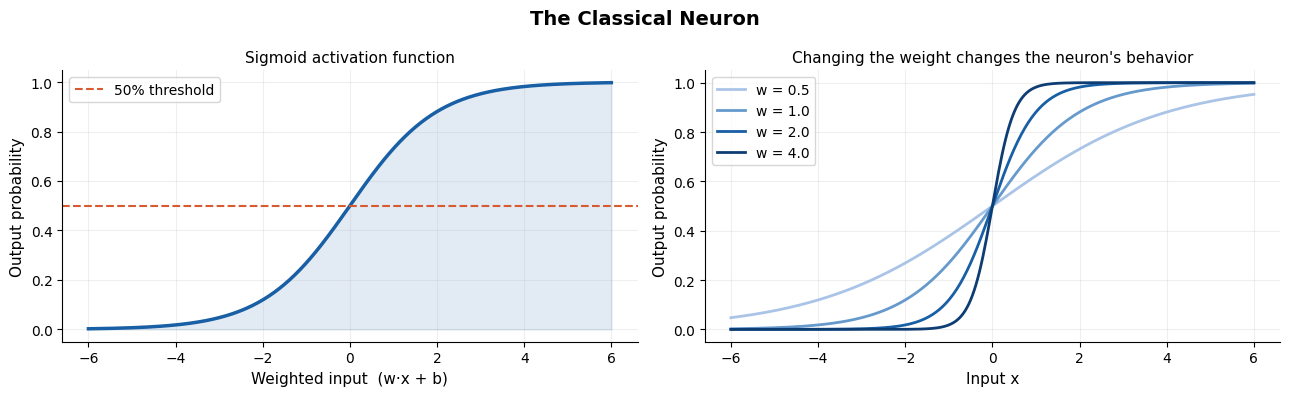

In [ ]:
# Visualizing a classical neuron
# The sigmoid function: output = 1 / (1 + e^{-x})
# As the weighted input grows, the "firing probability" rises from 0 to 1

x = np.linspace(-6, 6, 300)
sigmoid = 1 / (1 + np.exp(-x))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("The Classical Neuron", fontsize=14, fontweight="bold")

# Left: the activation function itself
axes[0].plot(x, sigmoid, color="#185FA5", lw=2.5)
axes[0].axhline(0.5, color="#D85A30", lw=1.5, linestyle="--", label="50% threshold")
axes[0].fill_between(x, sigmoid, alpha=0.12, color="#185FA5")
axes[0].set_xlabel("Weighted input  (w·x + b)", fontsize=11)
axes[0].set_ylabel("Output probability", fontsize=11)
axes[0].set_title("Sigmoid activation function", fontsize=11)
axes[0].legend(); axes[0].grid(alpha=0.2)
axes[0].spines[["top","right"]].set_visible(False)

# Right: what "learning" looks like — changing w steepens the curve
for w, c in zip([0.5, 1.0, 2.0, 4.0],
                ["#aac4e8","#6699cc","#185FA5","#0d3d73"]):
    axes[1].plot(x, 1/(1+np.exp(-w*x)), color=c, lw=2, label=f"w = {w}")
axes[1].set_xlabel("Input x", fontsize=11)
axes[1].set_ylabel("Output probability", fontsize=11)
axes[1].set_title("Changing the weight changes the neuron's behavior", fontsize=11)
axes[1].legend(); axes[1].grid(alpha=0.2)
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()


A quantum neuron works on the same principle. It has a tunable parameter that controls its output. Instead of a weight multiplying an input, we use a **rotation angle** that rotates a qubit's state.

The gate we'll use is **RY(θ)**, which rotates around the Y-axis of the Bloch sphere:

$$RY(\theta)\,|0\rangle = \cos\!\left(\frac{\theta}{2}\right)|0\rangle + \sin\!\left(\frac{\theta}{2}\right)|1\rangle$$

When we measure:
- $P(\text{measure } 0) = \cos^2(\theta/2)$
- $P(\text{measure } 1) = \sin^2(\theta/2)$

By tuning $\theta$, we control what the qubit "outputs." That $\theta$ is our trainable parameter, meaning the quantum equivalent of a weight.

**Step 4:** Now it is time to build our first quantum neuron!

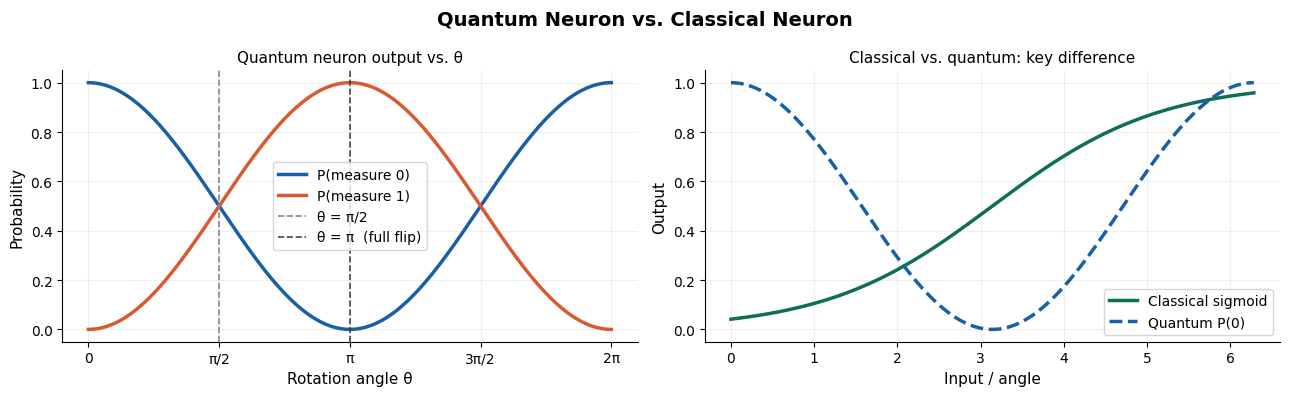

Key difference: the quantum neuron is PERIODIC. It wraps around every 2π.
The classical sigmoid saturates (flatlines). Quantum never does.

Circuit diagram:
0: ──RY(1.05)─┤  <Z>


In [ ]:
# Build our first quantum neuron

dev1 = qml.device("default.qubit", wires=1)

@qml.qnode(dev1)
def quantum_neuron(theta):
    qml.RY(theta, wires=0)           # rotate qubit by angle theta
    return qml.expval(qml.PauliZ(0)) # returns value in [-1, +1]

# Convert Z expectation value to probability:
#   P(measure 0) = (1 + <Z>) / 2

thetas   = np.linspace(0, 2*np.pi, 300)
z_vals   = np.array([quantum_neuron(t) for t in thetas])
prob0    = (1 + z_vals) / 2
prob1    = 1 - prob0

# Classical sigmoid for comparison (centered at pi)
sig = 1 / (1 + np.exp(-(thetas - np.pi)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Quantum Neuron vs. Classical Neuron", fontsize=14, fontweight="bold")

# Left: quantum neuron response
axes[0].plot(thetas, prob0, color="#185FA5", lw=2.5, label="P(measure 0)")
axes[0].plot(thetas, prob1, color="#D85A30", lw=2.5, label="P(measure 1)")
axes[0].axvline(np.pi/2, color="#888", lw=1.2, ls="--", label="θ = π/2")
axes[0].axvline(np.pi,   color="#444", lw=1.2, ls="--", label="θ = π  (full flip)")
axes[0].set_xlabel("Rotation angle θ", fontsize=11)
axes[0].set_ylabel("Probability", fontsize=11)
axes[0].set_title("Quantum neuron output vs. θ", fontsize=11)
axes[0].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
axes[0].set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])
axes[0].legend(); axes[0].grid(alpha=0.2)
axes[0].spines[["top","right"]].set_visible(False)

# Right: side-by-side comparison
axes[1].plot(thetas, sig,   color="#0F6E56", lw=2.5, label="Classical sigmoid")
axes[1].plot(thetas, prob0, color="#185FA5", lw=2.5, ls="--", label="Quantum P(0)")
axes[1].set_xlabel("Input / angle", fontsize=11)
axes[1].set_ylabel("Output", fontsize=11)
axes[1].set_title("Classical vs. quantum: key difference", fontsize=11)
axes[1].legend(); axes[1].grid(alpha=0.2)
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("Key difference: the quantum neuron is PERIODIC. It wraps around every 2π.")
print("The classical sigmoid saturates (flatlines). Quantum never does.")

# Also print the circuit diagram
print("\nCircuit diagram:")
print(qml.draw(quantum_neuron)(np.pi/3))


**Question:** At what angle θ does the quantum neuron give exactly 50% probability for each outcome? Can you read it off the plot?

Try replacing `qml.RY` with `qml.RX` in the cell above and re-running. Does the output probability curve look the same? Why or why not?

In [ ]:
#TODO

# **Milestone 2: More Knobs (Parameterized Circuits)**
---
One qubit with one parameter is limited. Real quantum models use **multiple qubits** and **multiple rotation angles**, connected by entangling gates (CNOT).

This is directly analogous to a neural network layer:

| Neural network | Quantum circuit |
|---------------|-----------------|
| Multiple neurons | Multiple qubits |
| Multiple weights | Multiple rotation angles |
| Connections between neurons | CNOT entangling gates |
| Layer | Block of rotations + CNOT |

Let's build a two-qubit parameterized circuit and see how the output landscape changes as we add entanglement.

**Step 1:**

In [ ]:
dev2 = qml.device("default.qubit", wires=2)

@qml.qnode(dev2)
def two_qubit_entangled(theta1, theta2):
    qml.RY(theta1, wires=0)   # rotate qubit 0
    qml.RY(theta2, wires=1)   # rotate qubit 1
    qml.CNOT(wires=[1, 0])    # entangle: qubit 1 flips if qubit 0 is |1>
    return qml.expval(qml.PauliZ(0))

@qml.qnode(dev2)
def two_qubit_no_entangle(theta1, theta2):
    qml.RY(theta1, wires=0)
    qml.RY(theta2, wires=1)
    # No CNOT — qubits are independent
    return qml.expval(qml.PauliZ(0))

print("Entangled circuit:")
print(qml.draw(two_qubit_entangled)(np.pi/3, np.pi/5))
print()
print("Non-entangled circuit:")
print(qml.draw(two_qubit_no_entangle)(np.pi/3, np.pi/5))

Entangled circuit:
0: ──RY(1.05)─╭X─┤  <Z>
1: ──RY(0.63)─╰●─┤     

Non-entangled circuit:
0: ──RY(1.05)─┤  <Z>
1: ──RY(0.63)─┤     


**Step 2:**

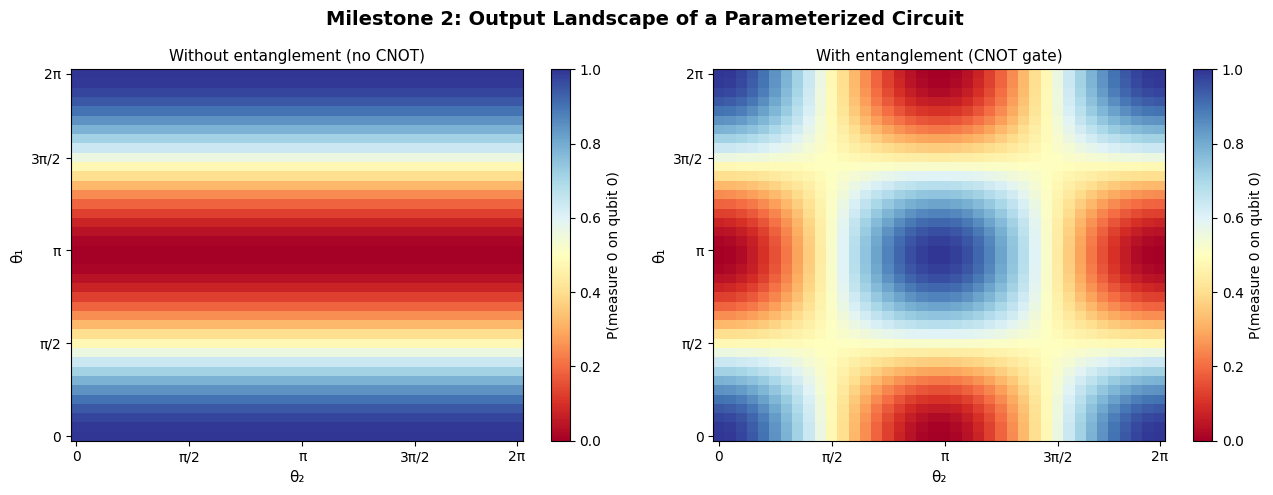

Left: output only depends on θ₁, varying θ₂ does nothing.
Right: CNOT creates coupling, θ₂ now also influences qubit 0's output.
Entanglement = more expressive model.


In [ ]:
# Build 2D output heatmaps (sweep both parameters)
# This shows the full "response surface" of each circuit

N = 40
t1 = np.linspace(0, 2*np.pi, N)
t2 = np.linspace(0, 2*np.pi, N)

grid_ent   = np.zeros((N, N))
grid_no    = np.zeros((N, N))

for i, a in enumerate(t1):
    for j, b in enumerate(t2):
        z_e = two_qubit_entangled(a, b)
        z_n = two_qubit_no_entangle(a, b)
        grid_ent[i, j] = (1 + float(z_e)) / 2
        grid_no[i, j]  = (1 + float(z_n)) / 2

tick_pos = [0, N//4, N//2, 3*N//4, N-1]
tick_lbl = ["0", "π/2", "π", "3π/2", "2π"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Milestone 2: Output Landscape of a Parameterized Circuit",
             fontsize=14, fontweight="bold")

for ax, grid, title in zip(axes,
    [grid_no, grid_ent],
    ["Without entanglement (no CNOT)", "With entanglement (CNOT gate)"]):

    im = ax.imshow(grid, origin="lower", cmap="RdYlBu", vmin=0, vmax=1, aspect="auto")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("θ₂", fontsize=11)
    ax.set_ylabel("θ₁", fontsize=11)
    ax.set_xticks(tick_pos); ax.set_xticklabels(tick_lbl)
    ax.set_yticks(tick_pos); ax.set_yticklabels(tick_lbl)
    plt.colorbar(im, ax=ax, label="P(measure 0 on qubit 0)")

plt.tight_layout()
plt.show()

print("Left: output only depends on θ₁, varying θ₂ does nothing.")
print("Right: CNOT creates coupling, θ₂ now also influences qubit 0's output.")
print("Entanglement = more expressive model.")



**Question**: Look at the two heatmaps. In the left plot, what happens to the output when you change θ₂? What does this tell you about the role of the CNOT gate in the right plot?

**Ans:**

# **Milestone 3: Teaching the Circuit and learning from data**
---

We have a parameterized circuit. Now we make it **learn**.

Learning = finding parameter values that make the circuit's output match what we want.

To do this we need two things:
1. A **loss function**: measures how wrong we currently are (lower = better)
2. **Gradient descent**: an algorithm to reduce the loss step by step

## Loss functions

The simplest loss function is **Mean Squared Error (MSE)**:

$$L(\theta) = \bigl(\text{output}(\theta) - \text{target}\bigr)^2$$

When $L = 0$, our circuit is perfect. When $L$ is large, we're off. Our job: minimize $L$.

**Step 1:** Let's start by visualizing the loss landscape for our single qubit circuit. Run the next cell.


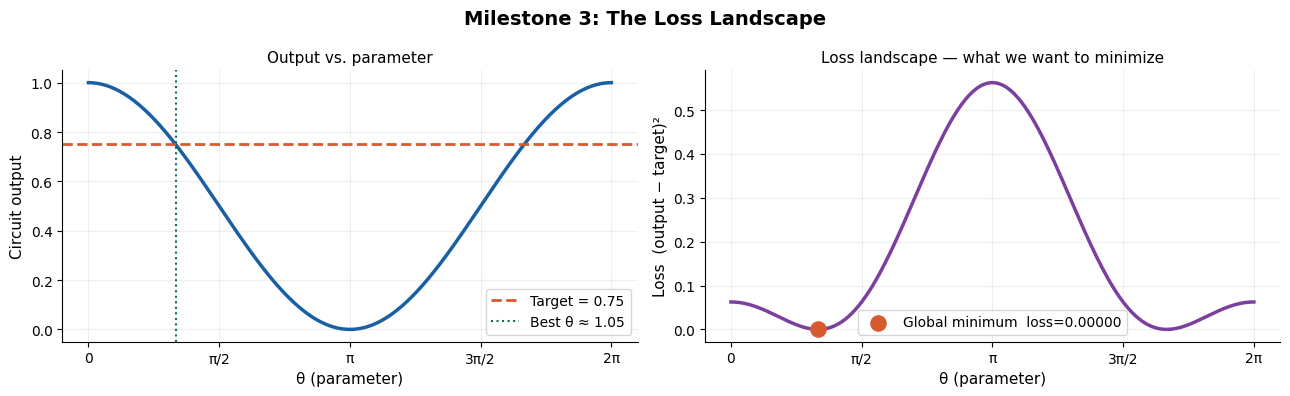

Optimal θ ≈ 1.051  →  output ≈ 0.7485  (target = 0.75)


In [ ]:
# Visualizing the loss landscape for our single qubit circuit
target_output = 0.75   # We want the circuit to output probability 0.75

thetas_full = np.linspace(0, 2*np.pi, 300)
outputs     = np.array([(1 + float(quantum_neuron(t))) / 2 for t in thetas_full])
losses      = (outputs - target_output)**2

min_idx     = np.argmin(losses)
best_theta  = thetas_full[min_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Milestone 3: The Loss Landscape", fontsize=14, fontweight="bold")

# Left: output vs theta
axes[0].plot(thetas_full, outputs, color="#185FA5", lw=2.5)
axes[0].axhline(target_output, color="#D85A30", lw=2, ls="--",
                label=f"Target = {target_output}")
axes[0].axvline(best_theta, color="#0F6E56", lw=1.5, ls=":",
                label=f"Best θ ≈ {best_theta:.2f}")
axes[0].set_xlabel("θ (parameter)", fontsize=11)
axes[0].set_ylabel("Circuit output", fontsize=11)
axes[0].set_title("Output vs. parameter", fontsize=11)
axes[0].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
axes[0].set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])
axes[0].legend(); axes[0].grid(alpha=0.2)
axes[0].spines[["top","right"]].set_visible(False)

# Right: loss vs theta
axes[1].plot(thetas_full, losses, color="#7B3FA0", lw=2.5)
axes[1].scatter([best_theta], [losses[min_idx]], color="#D85A30", s=120, zorder=5,
                label=f"Global minimum  loss={losses[min_idx]:.5f}")
axes[1].set_xlabel("θ (parameter)", fontsize=11)
axes[1].set_ylabel("Loss  (output − target)²", fontsize=11)
axes[1].set_title("Loss landscape — what we want to minimize", fontsize=11)
axes[1].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
axes[1].set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])
axes[1].legend(); axes[1].grid(alpha=0.2)
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Optimal θ ≈ {best_theta:.3f}  →  output ≈ {outputs[min_idx]:.4f}  (target = {target_output})")


**Step 2:** Now we need to understand the gradient descent.

We found the minimum by brute force above (evaluating every θ). For models with hundreds of parameters, that's impossible.

**Gradient descent** finds the minimum step by step:
1. Start at a random point
2. Compute the slope at that point (the gradient)
3. Take a small step downhill
4. Repeat

$$\theta_{\text{new}} = \theta_{\text{old}} - \underbrace{\alpha}_{\text{learning rate}} \cdot \underbrace{\frac{dL}{d\theta}}_{\text{gradient}}$$

The **learning rate** α controls how big each step is. If it is too large it is overshoot. If it is too small, it is slow.

For quantum circuits, PennyLane computes gradients using the **parameter-shift rule**.

**Step 3:** Let's understand the gradient descent in action

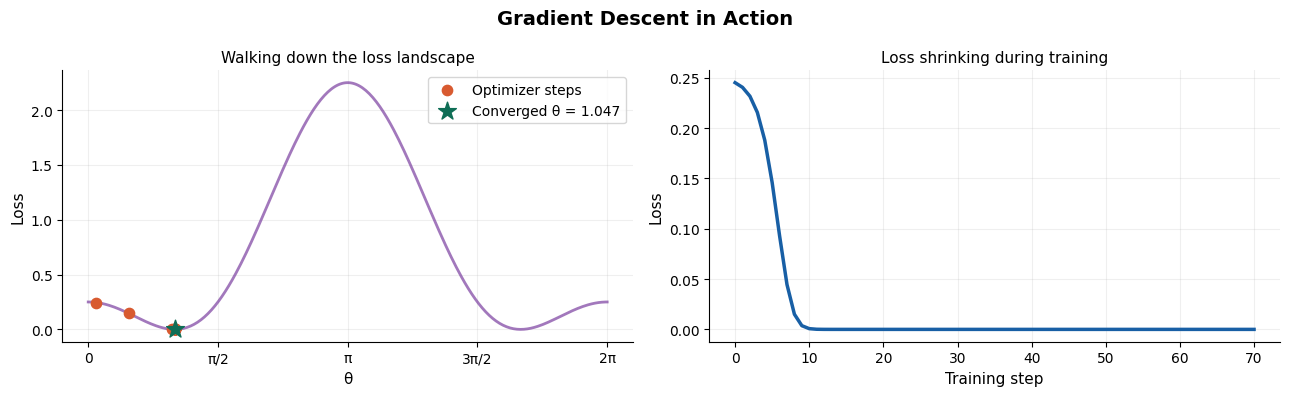

Target probability : 0.750
Achieved probability: 0.7500
Final loss         : 0.0000000


In [ ]:
# Watch gradient descent find the minimum

dev_gd = qml.device("default.qubit", wires=1)

@qml.qnode(dev_gd)
def single_qubit(theta):
    qml.RY(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

target_z = 2 * 0.75 - 1   # convert probability 0.75 → Z expectation 0.5

def loss_fn(theta):
    return (single_qubit(theta) - target_z) ** 2

# Gradient descent optimizer
theta = np.array(0.1, requires_grad=True)   # random starting point
opt   = qml.GradientDescentOptimizer(stepsize=0.4)

theta_hist = [float(theta)]
loss_hist  = [float(loss_fn(theta))]

for _ in range(70):
    theta = opt.step(loss_fn, theta)
    theta_hist.append(float(theta))
    loss_hist.append(float(loss_fn(theta)))

# plots
loss_landscape = np.array([float(loss_fn(np.array(t, requires_grad=False)))
                            for t in thetas_full])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Gradient Descent in Action", fontsize=14, fontweight="bold")

# Left: path on loss landscape
axes[0].plot(thetas_full, loss_landscape, color="#7B3FA0", lw=2, alpha=0.7)
sampled_thetas = theta_hist[::5]
sampled_losses = [float(loss_fn(np.array(t, requires_grad=False))) for t in sampled_thetas]
axes[0].scatter(sampled_thetas, sampled_losses, color="#D85A30", s=55, zorder=5,
                label="Optimizer steps")
axes[0].scatter([theta_hist[-1]], [loss_hist[-1]], color="#0F6E56", s=180,
                marker="*", zorder=6, label=f"Converged θ = {theta_hist[-1]:.3f}")
axes[0].set_xlabel("θ", fontsize=11)
axes[0].set_ylabel("Loss", fontsize=11)
axes[0].set_title("Walking down the loss landscape", fontsize=11)
axes[0].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
axes[0].set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])
axes[0].legend(); axes[0].grid(alpha=0.2)
axes[0].spines[["top","right"]].set_visible(False)

# Right: loss over training steps
axes[1].plot(loss_hist, color="#185FA5", lw=2.5)
axes[1].set_xlabel("Training step", fontsize=11)
axes[1].set_ylabel("Loss", fontsize=11)
axes[1].set_title("Loss shrinking during training", fontsize=11)
axes[1].grid(alpha=0.2)
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

final_p = (1 + float(single_qubit(theta))) / 2
print(f"Target probability : 0.750")
print(f"Achieved probability: {final_p:.4f}")
print(f"Final loss         : {loss_hist[-1]:.7f}")

# **Milestone 4: A Real Quantum Classifier**
---

Now we put it all together. We'll train a quantum circuit to **classify** real data.

**Classification:** given a data point, predict which category it belongs to.

We'll use the circles dataset, two concentric rings that no straight line can separate. It's a standard benchmark for non-linear classifiers.
**The pipeline:**
1. Generate and visualize the data
2. Encode data features as qubit rotation angles
3. Build a variational quantum circuit (the model)
4. Train with gradient descent
5. Evaluate and visualize the decision boundary

**Step 1:** Let's generate and plot the dataset

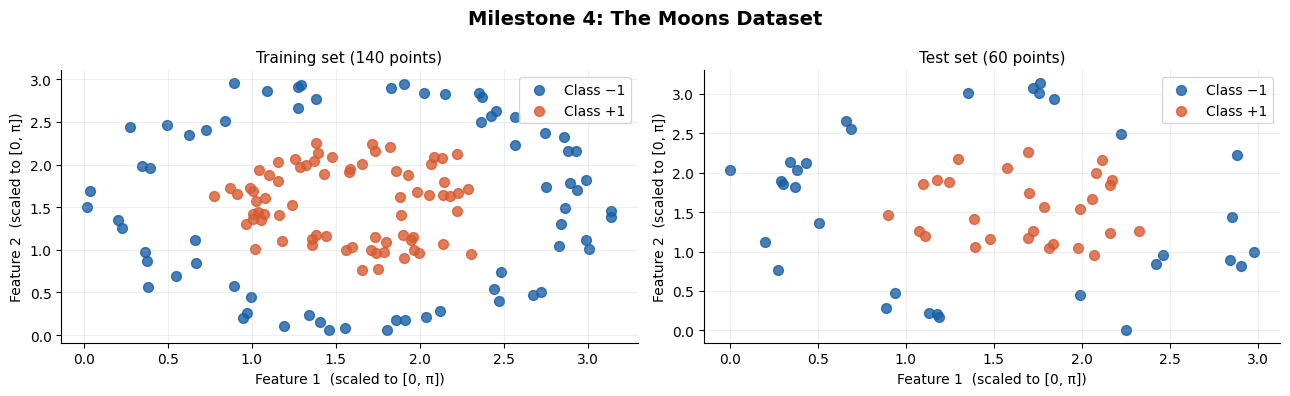

The two classes are interleaved, no straight line can separate them!
This requires a non-linear model.


In [ ]:
# Generate and plot the dataset

np.random.seed(42)

from sklearn.datasets import make_circles
X_raw, y_raw = make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=42)

# Scale features to [0, π] — the natural input range for RY rotation gates
scaler  = MinMaxScaler(feature_range=(0, np.pi))
X_sc    = scaler.fit_transform(X_raw)

# Labels: convert {0,1} → {-1,+1} to match the Z-measurement output range
y_pm = 2 * y_raw - 1

X_train, X_test, y_train, y_test = train_test_split(
    X_sc, y_pm, test_size=0.3, random_state=42)

# plot
CLR = {-1: "#185FA5", 1: "#D85A30"}
LBL = {-1: "Class −1", 1: "Class +1"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Milestone 4: The Circles Dataset", fontsize=14, fontweight="bold")

for cls in [-1, 1]:
    axes[0].scatter(X_train[y_train==cls,0], X_train[y_train==cls,1],
                    color=CLR[cls], label=LBL[cls], alpha=0.8, s=50)
    axes[1].scatter(X_test[y_test==cls,0],  X_test[y_test==cls,1],
                    color=CLR[cls], label=LBL[cls], alpha=0.8, s=50)

for ax, title in zip(axes, [f"Training set ({len(X_train)} points)",
                              f"Test set ({len(X_test)} points)"]):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Feature 1  (scaled to [0, π])", fontsize=10)
    ax.set_ylabel("Feature 2  (scaled to [0, π])", fontsize=10)
    ax.legend(); ax.grid(alpha=0.2)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()
print("The two classes are concentric rings, no straight line can separate them!")
print("This requires a non-linear model.")



**Angle encoding** is the simplest approach: map each feature $x_i$ to a qubit rotation:

$$x_i \;\longrightarrow\; RY(x_i)\,|0\rangle$$

Our 2D data point $(x_1, x_2)$ becomes rotations on 2 qubits. That's why we scaled features to $[0, \pi]$. It covers the informative range of RY.

After encoding, we apply trainable rotation layers on top. Those are our "weights."

In [ ]:
# Build the variational quantum classifier

dev_clf = qml.device("default.qubit", wires=2)

@qml.qnode(dev_clf)
def vqc(inputs, weights):
    # Encode data
    qml.RY(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)

    # Trainable layer 1
    qml.Rot(weights[0,0], weights[0,1], weights[0,2], wires=0)
    qml.Rot(weights[1,0], weights[1,1], weights[1,2], wires=1)
    qml.CNOT(wires=[0, 1])   # entangle

    # Trainable layer 2
    qml.Rot(weights[2,0], weights[2,1], weights[2,2], wires=0)
    qml.Rot(weights[3,0], weights[3,1], weights[3,2], wires=1)
    qml.CNOT(wires=[1, 0])   # entangle (reversed direction)

    return qml.expval(qml.PauliZ(0))   # positive = class +1, negative = class −1

def predict(x, w, b):
    return vqc(x, w) + b

def accuracy(w, b, X, y):
    return np.mean(np.sign([predict(x, w, b) for x in X]) == y)

print("Variational Quantum Classifier circuit:")
print(qml.draw(vqc)(np.array([0.5, 0.5]), np.zeros((4,3))))
print()
print("Trainable parameters: 4 layers × 3 angles = 12 rotation angles + 1 bias = 13 total")

Variational Quantum Classifier circuit:
0: ──RY(0.50)──Rot(0.00,0.00,0.00)─╭●──Rot(0.00,0.00,0.00)─╭X─┤  <Z>
1: ──RY(0.50)──Rot(0.00,0.00,0.00)─╰X──Rot(0.00,0.00,0.00)─╰●─┤     

Trainable parameters: 4 layers × 3 angles = 12 rotation angles + 1 bias = 13 total


**Step 2:** Now it is time to train the classifier! When you run the cell, it will take a few minutes, so just wait!

In [ ]:
# Train the classifier

np.random.seed(42)
W = np.random.randn(4, 3, requires_grad=True) * 0.1
b = np.array(0.0, requires_grad=True)

opt = qml.AdamOptimizer(0.05)

loss_log = []
acc_log  = []

print("Training...")
print(f"{'Step':>5}  {'Loss':>7}  {'Train Acc':>9}  {'Test Acc':>8}")
print("─" * 36)

for step in range(120):
    def cost(w, bias):
        preds = np.array([predict(x, w, bias) for x in X_train])
        return np.mean((preds - y_train) ** 2)

    W, b = opt.step(cost, W, b)

    if step % 15 == 0 or step == 119:
        l  = float(cost(W, b))
        at = float(accuracy(W, b, X_train, y_train))
        ae = float(accuracy(W, b, X_test,  y_test))
        loss_log.append(l)
        acc_log.append(ae)
        print(f"{step:>5}  {l:>7.4f}  {at:>9.3f}  {ae:>8.3f}")

print()
print(f"Final test accuracy: {accuracy(W, b, X_test, y_test):.3f}")

Training...
 Step     Loss  Train Acc  Test Acc
────────────────────────────────────
    0   1.3132      0.493     0.533
   15   0.6870      0.964     0.950
   30   0.6209      0.971     0.933
   45   0.5295      0.993     0.967
   60   0.5118      0.986     0.983
   75   0.5091      0.993     1.000
   90   0.5091      0.993     1.000
  105   0.5090      0.993     0.983
  119   0.5089      0.993     0.983

Final test accuracy: 0.983


**Step 3:** Now let's visualize the training curves!

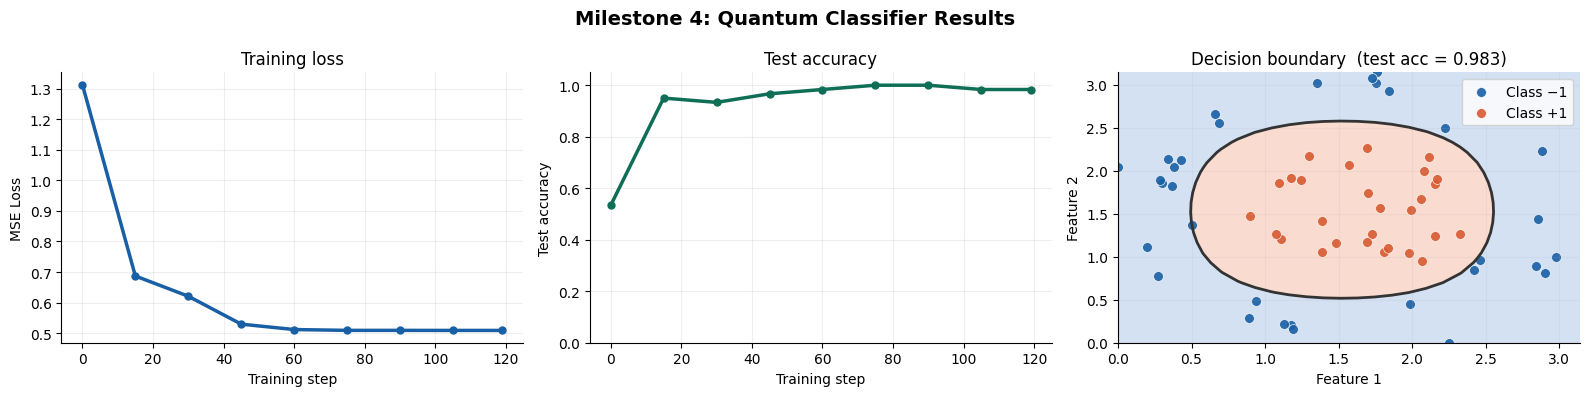

In [ ]:
# Visualize training curves and decision boundary

RES = 28
g1  = np.linspace(0, np.pi, RES)
g2  = np.linspace(0, np.pi, RES)
xx, yy = np.meshgrid(g1, g2)
grid   = np.column_stack([xx.ravel(), yy.ravel()])
ZZ     = np.array([float(predict(p, W, b)) for p in grid]).reshape(RES, RES)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Milestone 4: Quantum Classifier Results", fontsize=14, fontweight="bold")

steps_logged = list(range(0, 120, 15)) + [119]

# Loss
axes[0].plot(steps_logged, loss_log, color="#185FA5", lw=2.5, marker="o", ms=5)
axes[0].set_xlabel("Training step"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training loss"); axes[0].grid(alpha=0.2)
axes[0].spines[["top","right"]].set_visible(False)

# Accuracy
axes[1].plot(steps_logged, acc_log, color="#0F6E56", lw=2.5, marker="o", ms=5)
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel("Training step"); axes[1].set_ylabel("Test accuracy")
axes[1].set_title("Test accuracy"); axes[1].grid(alpha=0.2)
axes[1].spines[["top","right"]].set_visible(False)

# Decision boundary
axes[2].contourf(xx, yy, ZZ, levels=[-2, 0, 2],
                 colors=["#aac4e8","#f5b8a0"], alpha=0.5)
axes[2].contour(xx, yy, ZZ, levels=[0], colors=["#333"], linewidths=2)
for cls in [-1, 1]:
    m = y_test == cls
    axes[2].scatter(X_test[m,0], X_test[m,1], color=CLR[cls],
                    label=LBL[cls], s=50, alpha=0.9, edgecolors="white", lw=0.5)
axes[2].set_xlabel("Feature 1"); axes[2].set_ylabel("Feature 2")
axes[2].set_title(f"Decision boundary  (test acc = {accuracy(W,b,X_test,y_test):.3f})")
axes[2].legend(); axes[2].grid(alpha=0.15)
axes[2].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

**Question:** Look at the decision boundary. Is it a straight line? What does this tell you about the quantum classifier's ability to learn non-linear patterns?

**Ans:**

Increase training to 200 steps by changing `range(120)` to `range(200)`. Does accuracy keep improving? What might explain when it stops?

In [ ]:
#TODO

# **Milestone 5: Quantum vs. Classical Comparison**
---

We've built a quantum classifier. The important question: **does it actually win?**

Let's train two classical models on the exact same data and compare fairly.

**Step 1:** Let's train classical baselines

In [ ]:
# Train classical baselines on the same train/test split

# 1. Logistic Regression (linear classifier)
t0 = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_time = time.time() - t0
lr_acc  = accuracy_score(y_test, lr.predict(X_test))
lr_params = X_train.shape[1] + 1   # 2 weights + 1 bias

# 2. Small Neural Network (8 hidden neurons)
t0 = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(8,), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
mlp_time = time.time() - t0
mlp_acc  = accuracy_score(y_test, mlp.predict(X_test))
mlp_params = 2*8 + 8 + 8*2 + 2     # rough count

# 3. Quantum model (already trained above)
qml_acc = float(accuracy(W, b, X_test, y_test))

print("=" * 60)
print(f"{'Model':<25} {'Test Acc':>8}  {'# Params':>9}  {'Train Time':>11}")
print("─" * 60)
print(f"{'Logistic Regression':<25} {lr_acc:>8.3f}  {lr_params:>9}  {lr_time*1000:>8.1f} ms")
print(f"{'Neural Network (8)':<25} {mlp_acc:>8.3f}  {mlp_params:>9}  {mlp_time*1000:>8.1f} ms")
print(f"{'Quantum Classifier':<25} {qml_acc:>8.3f}  {13:>9}  {'~2 min':>11}")
print("=" * 60)

Model                     Test Acc   # Params   Train Time
────────────────────────────────────────────────────────────
Logistic Regression          0.433          3       3.5 ms
Neural Network (8)           0.900         42     292.3 ms
Quantum Classifier           0.983         13       ~2 min


**Step 2:** Plot all three decision boundaries side by side

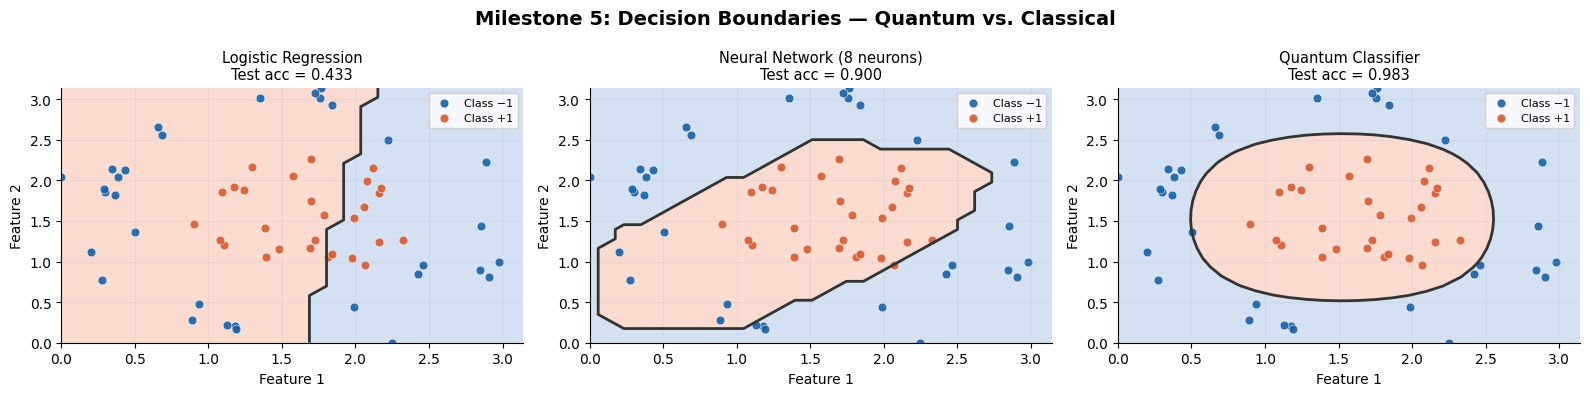

In [ ]:
# All three decision boundaries side by side

# Pre-compute classical boundaries on the same grid
lr_Z  = lr.predict(grid).reshape(RES, RES).astype(float)
lr_Z  = np.where(lr_Z == 1, 1.0, -1.0)
mlp_Z = mlp.predict(grid).reshape(RES, RES).astype(float)
mlp_Z = np.where(mlp_Z == 1, 1.0, -1.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Milestone 5: Decision Boundaries — Quantum vs. Classical",
             fontsize=14, fontweight="bold")

for ax, Z_plot, title, acc in zip(axes,
    [lr_Z, mlp_Z, ZZ],
    ["Logistic Regression", "Neural Network (8 neurons)", "Quantum Classifier"],
    [lr_acc, mlp_acc, qml_acc]):

    ax.contourf(xx, yy, Z_plot, levels=[-2, 0, 2],
                colors=["#aac4e8","#f5b8a0"], alpha=0.5)
    ax.contour(xx, yy, Z_plot, levels=[0], colors=["#333"], linewidths=2)
    for cls in [-1, 1]:
        m = y_test == cls
        ax.scatter(X_test[m,0], X_test[m,1], color=CLR[cls],
                   label=LBL[cls], s=40, alpha=0.9, edgecolors="white", lw=0.4)
    ax.set_title(f"{title}\nTest acc = {acc:.3f}", fontsize=10.5)
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
    ax.legend(fontsize=8); ax.grid(alpha=0.15)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

**Questions:** Based on the comparison table, what is the quantum classifier's biggest practical disadvantage today?

**Ans:**

In 3–4 sentences, explain to a friend with no quantum background: what is quantum machine learning, why might it matter, and what is the biggest open question?

**Ans:**

### Want to go further? Start here

1. Our curated NSDC resources on Quantum computing: (https://nebigdatahub.org/quantum-initiative/)

2. **[PennyLane QML demonstrations](https://pennylane.ai/qml/demonstrations/)**: hands-on, free, well-written. Best next step.
3. **[Google Quantum AI resources](https://quantumai.google/resources)**: real hardware experiments explained accessibly.

<h3 align = 'center' >
Thank you for completing the project!
</h3>

Please submit all materials to the NSDC HQ team at er3101@columbia.edu in order to receive a virtual certificate of completion. Do reach out to us if you have any questions or concerns. We are here to help you learn and grow.